# First Quantum Layers: Classifying Iris with MerLin

This notebook walks through three complementary ways to instantiate `QuantumLayer` objects and trains each on the classic Iris classification task.

We will reuse a common data pipeline and optimisation loop while switching between the following APIs:

1. `QuantumLayer.simple` quickstart factory.
2. Declarative `CircuitBuilder` pipeline.
3. A fully manual `perceval.Circuit`.

You can run the cells top-to-bottom to reproduce the reported metrics !

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from merlin import LexGrouping, QuantumLayer
from merlin.builder import CircuitBuilder

torch.manual_seed(0)
np.random.seed(0)

iris = load_iris()
X = iris.data.astype("float32")
y = iris.target.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True).clamp_min(1e-6)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

Train size: 112 samples
Test size: 38 samples


In [2]:
# here is a function to run an experiment : train and evaluate a QuantumLayer


def run_experiment(layer: torch.nn.Module, epochs: int = 60, lr: float = 0.05):
    optimizer = torch.optim.Adam(layer.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        layer.train()
        optimizer.zero_grad()
        logits = layer(X_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    layer.eval()
    with torch.no_grad():
        train_preds = layer(X_train).argmax(dim=1)
        test_preds = layer(X_test).argmax(dim=1)
        train_acc = (train_preds == y_train).float().mean().item()
        test_acc = (test_preds == y_test).float().mean().item()
    return losses, train_acc, test_acc


def describe(name: str, losses, train_acc: float, test_acc: float):
    print(name)
    print(f"  epochs: {len(losses)}")
    print(f"  final loss: {losses[-1]:.4f}")
    print(f"  train accuracy: {train_acc:.3f}")
    print(f"  test accuracy: {test_acc:.3f}")

## 1. Quickstart factory: `QuantumLayer.simple`

The quickstart helper allocates a ready-to-train (input_size+1)-mode, (ceil((input_size+1)/2))-photon circuit.

In [3]:
base_simple = QuantumLayer.simple(
    input_size=X_train.shape[1],
    dtype=X_train.dtype,
)

simple_layer = nn.Sequential(
    base_simple,
    LexGrouping(base_simple.output_size, 3),
)

losses, train_acc, test_acc = run_experiment(simple_layer, epochs=80, lr=0.01)
trainable = sum(p.numel() for p in simple_layer.parameters() if p.requires_grad)
describe("QuantumLayer.simple", losses, train_acc, test_acc)
print(
    f"  trainable parameters: {trainable}"
)  # this will also print the number of trainable parameters in the last Linear layer

# this circuit does not work well on this dataset, let us try another circuit !

QuantumLayer.simple
  epochs: 80
  final loss: 0.8519
  train accuracy: 0.732
  test accuracy: 0.658
  trainable parameters: 40


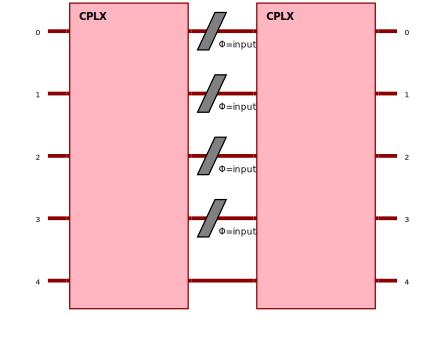

In [4]:
# you can visualize the circuit generated by QuantumLayer.simple
pcvl.pdisplay(base_simple.circuit)

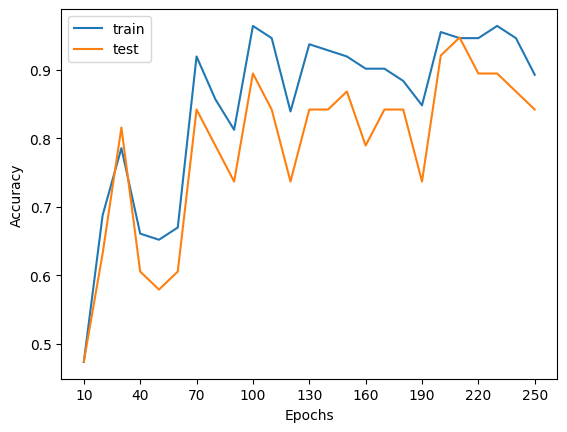

In [5]:
test_accs, train_accs = [], []
epochs = [10 * i for i in range(1, 26)]
for epoch in epochs:
    base_layer = QuantumLayer.simple(
        input_size=X_train.shape[1],
        dtype=X_train.dtype,
    )
    simple_layer = nn.Sequential(
        base_layer,
        LexGrouping(base_layer.output_size, 3),
    )
    losses, train_acc, test_acc = run_experiment(simple_layer, epochs=epoch, lr=0.01)
    test_accs.append(test_acc)
    train_accs.append(train_acc)
plt.plot(epochs, train_accs, label="train")
plt.plot(epochs, test_accs, label="test")
ticks = epochs
indexes_to_pop = []
index = 0
for i in range(len(epochs)):
    if i % 3 > 0:
        ticks.pop(index)
    else:
        index += 1

plt.xticks(ticks=ticks, labels=[str(p) for p in ticks])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 2. Declarative builder API

`CircuitBuilder` offers a fluent interface to assemble interferometers, encoders, and trainable blocks before handing the result to `QuantumLayer`.

In [6]:
builder = CircuitBuilder(n_modes=6)
builder.add_entangling_layer(trainable=True, name="U1")
builder.add_angle_encoding(modes=list(range(X_train.shape[1])), name="input")
builder.add_rotations(trainable=True, name="theta")
builder.add_superpositions(depth=1)
builder_core = QuantumLayer(
    input_size=X_train.shape[1],
    builder=builder,
    n_photons=3,  # equivalent to input_state = [1,1,1,0,0,0]
    dtype=X_train.dtype,
)
builder_layer = nn.Sequential(
    builder_core,
    LexGrouping(builder_core.output_size, 3),
)
losses, train_acc, test_acc = run_experiment(builder_layer, epochs=80, lr=0.05)
trainable = sum(p.numel() for p in builder_layer.parameters() if p.requires_grad)
describe("CircuitBuilder pipeline", losses, train_acc, test_acc)
print(f"  trainable parameters: {trainable}")

CircuitBuilder pipeline
  epochs: 80
  final loss: 0.7887
  train accuracy: 0.848
  test accuracy: 0.789
  trainable parameters: 36


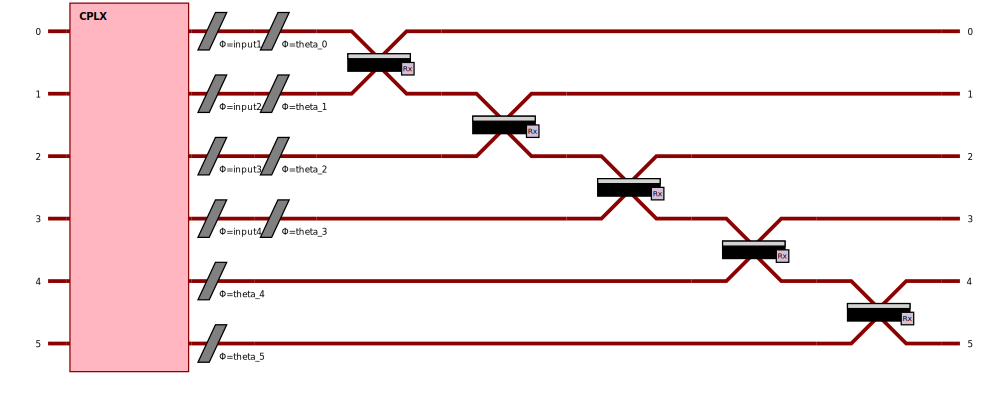

In [7]:
# you can observe your circuit
pcvl.pdisplay(builder_core.circuit)

## 3. Hand-crafted Perceval circuit

When full control is required, build a `perceval.Circuit` manually and pass it to `QuantumLayer` alongside the parameter prefixes to train and encode.

In [8]:
modes = 6

wl = pcvl.GenericInterferometer(
    modes,
    lambda i: (
        pcvl.BS()
        // pcvl.PS(pcvl.P(f"theta_li{i}"))
        // pcvl.BS()
        // pcvl.PS(pcvl.P(f"theta_lo{i}"))
    ),
    shape=pcvl.InterferometerShape.RECTANGLE,
)
circuit = pcvl.Circuit(modes)
circuit.add(0, wl)
for mode in range(len(iris.feature_names)):
    circuit.add(mode, pcvl.PS(pcvl.P(f"input{mode}")))
wr = pcvl.GenericInterferometer(
    modes,
    lambda i: (
        pcvl.BS()
        // pcvl.PS(pcvl.P(f"theta_ri{i}"))
        // pcvl.BS()
        // pcvl.PS(pcvl.P(f"theta_ro{i}"))
    ),
    shape=pcvl.InterferometerShape.RECTANGLE,
)
circuit.add(0, wr)

manual_core = QuantumLayer(
    input_size=X_train.shape[1],
    circuit=circuit,
    input_state=[
        1,
        0,
        1,
        0,
        1,
        0,
    ],  # here, you can just precise the n_photons -> input_state = [1,1,1,0,0,0]
    trainable_parameters=["theta"],
    input_parameters=["input"],
    dtype=X_train.dtype,
)

manual_layer = nn.Sequential(
    manual_core,
    LexGrouping(manual_core.output_size, 3),
)

losses, train_acc, test_acc = run_experiment(manual_layer, epochs=120, lr=0.05)
trainable = sum(p.numel() for p in manual_layer.parameters() if p.requires_grad)
describe("Manual Perceval circuit", losses, train_acc, test_acc)
print(f"  trainable parameters: {trainable}")

Manual Perceval circuit
  epochs: 120
  final loss: 0.7080
  train accuracy: 0.973
  test accuracy: 0.921
  trainable parameters: 60


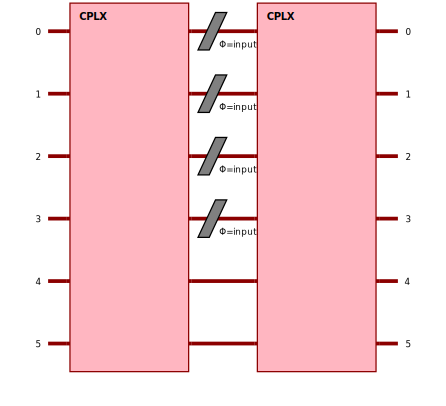

In [9]:
# you can visualize the circuit
pcvl.pdisplay(manual_core.circuit)